In [ ]:
!pip install -q xgboost

Loaded: heart_disease.csv | Shape: (10000, 21)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No



Missing values per column:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
dtype: int64


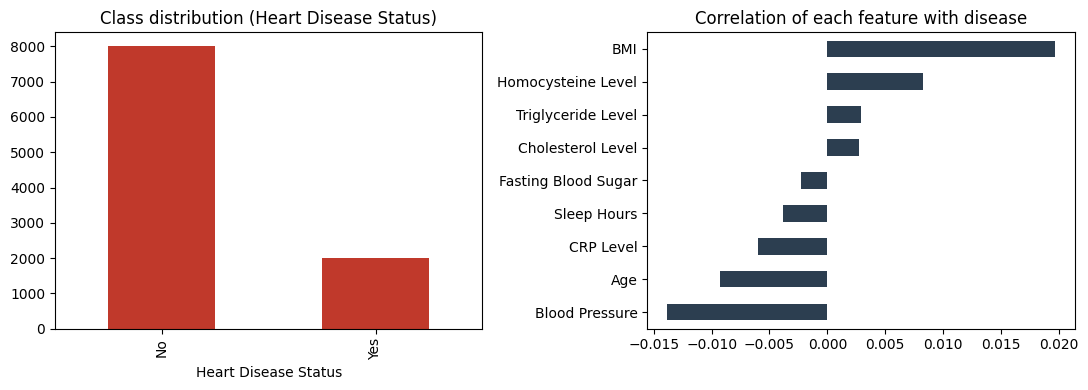


Samples: 10000 | Features: 20 | Target: 'Heart Disease Status'
Class balance (1 = disease): {0: 8000, 1: 2000}
Numeric    : ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
Categorical: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']
Train size: 8000 | Test size: 2000

>>> Logistic Regression
Best params: {'clf__C': 0.01}
              precision    recall  f1-score   support

  No disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000


>>> SVM
Best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
       

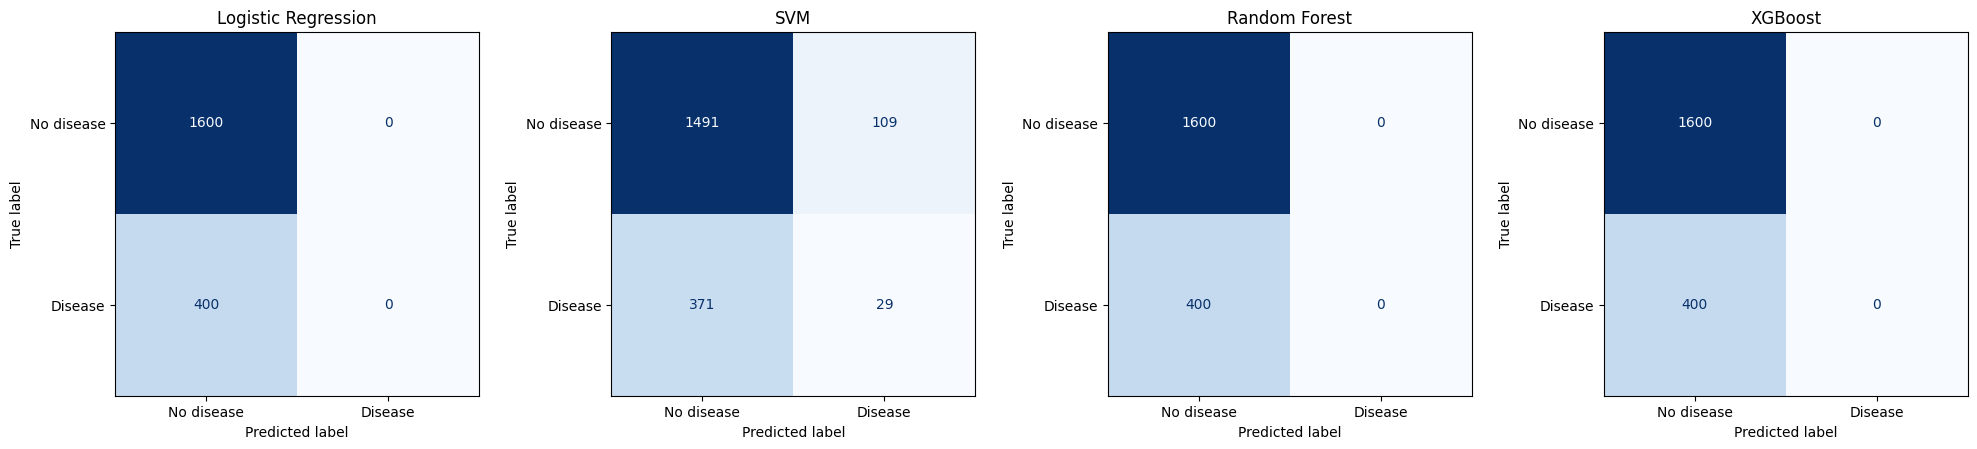

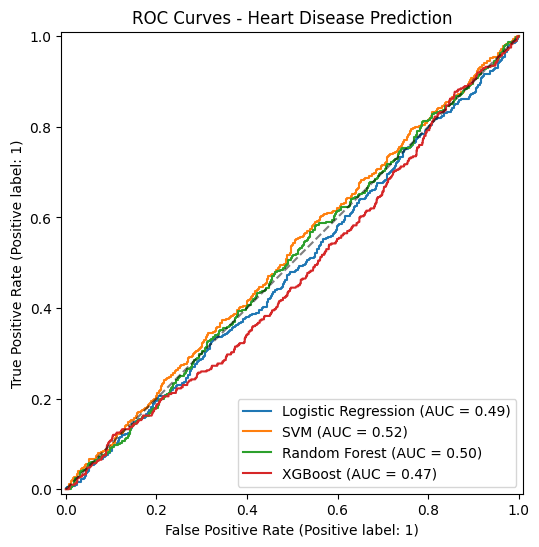


MODEL COMPARISON (held-out test set)


,Model,CV ROC-AUC,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,0.5143,0.76,0.2101,0.0725,0.1078,0.5154
1,Random Forest,0.5076,0.80,0.0000,0.0000,0.0000,0.5017
2,Logistic Regression,0.5118,0.80,0.0000,0.0000,0.0000,0.4853
3,XGBoost,0.5151,0.80,0.0000,0.0000,0.0000,0.4712


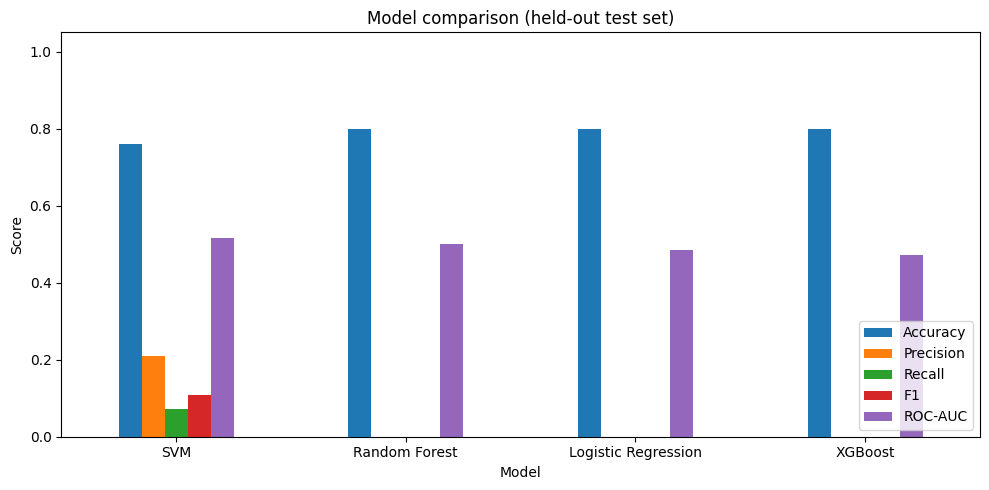

Best model (by CV ROC-AUC): XGBoost


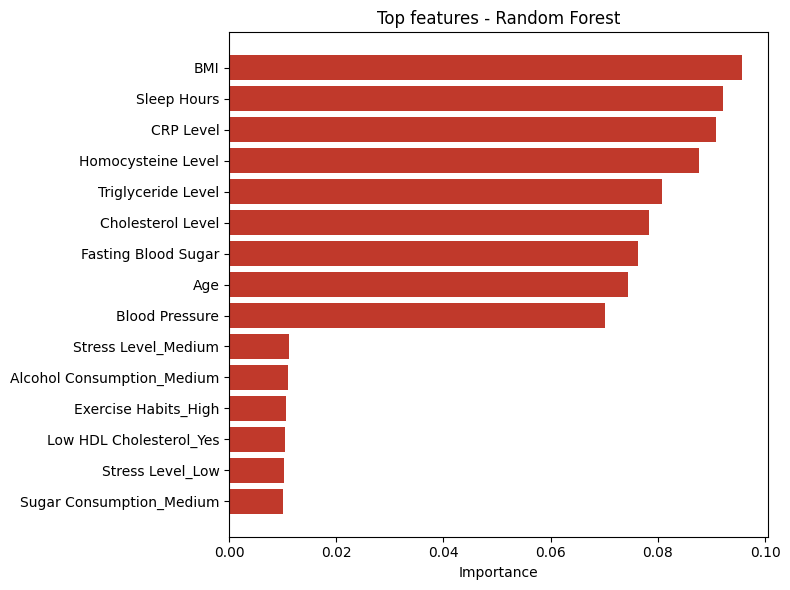

Probability of disease : 21.3%
Prediction             : LOW risk of heart disease
Note: ML estimate for learning purposes, not a medical diagnosis.


In [ ]:


import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score,
                             classification_report, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed -> XGBoost will be skipped (pip install xgboost)")

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


DATA_PATH = "heart_disease.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("heart_disease.csv not found. Please upload it:")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("heart_disease.csv not found in the current folder.")

TARGET_CANDIDATES = ["target", "num", "heartdisease", "heart_disease", "output",
                     "disease", "condition", "class", "label", "status", "diagnosis"]

def find_target_column(df):
    lowered = {c.lower().strip(): c for c in df.columns}
    for name in TARGET_CANDIDATES:
        if name in lowered:
            return lowered[name]
    return df.columns[-1]

df = pd.read_csv(DATA_PATH, na_values=["?", "NA", "N/A", "", " "])
df.columns = [c.strip() for c in df.columns]
print("Loaded:", DATA_PATH, "| Shape:", df.shape)
display(df.head())
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])


target_col = find_target_column(df)
if pd.api.types.is_numeric_dtype(df[target_col]):
    y_bin = (df[target_col] > 0).astype(int)
else:
    y_bin = pd.Series(LabelEncoder().fit_transform(df[target_col].astype(str)), index=df.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df[target_col].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#c0392b")
axes[0].set_title(f"Class distribution ({target_col})")
num_cols = df.select_dtypes("number").drop(columns=[target_col], errors="ignore")
num_cols.corrwith(y_bin).sort_values().plot(kind="barh", ax=axes[1], color="#2c3e50")
axes[1].set_title("Correlation of each feature with disease")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. PREPARE DATA
# ------------------------------------------------------------------
def load_data(df):
    df = df.drop_duplicates().reset_index(drop=True)
    target_col = find_target_column(df)
    df = df.dropna(subset=[target_col])

    y_raw = df[target_col]
    X = df.drop(columns=[target_col])

    # Binary target: 0 = no disease, 1 = disease
    if pd.api.types.is_numeric_dtype(y_raw):
        y = (y_raw > 0).astype(int)           # UCI 'num' is 0-4 -> any value > 0 = disease
    else:
        y = pd.Series(LabelEncoder().fit_transform(y_raw.astype(str)), index=y_raw.index)

    # Convert numeric-looking text columns to numbers
    for col in X.columns:
        if X[col].dtype == object:
            conv = pd.to_numeric(X[col], errors="coerce")
            if conv.notna().sum() >= 0.9 * X[col].notna().sum():
                X[col] = conv
    return X, y, target_col


def split_feature_types(X):
    """Numeric columns with only 3-5 distinct values (cp, slope, thal, ca...) are treated as categories."""
    categorical, numeric = [], []
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            categorical.append(col)
        elif 2 < X[col].nunique() <= 5:
            categorical.append(col)
        else:
            numeric.append(col)
    return numeric, categorical


def build_preprocessor(numeric, categorical):
    numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                             ("scale", StandardScaler())])
    categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                 ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([("num", numeric_pipe, numeric),
                              ("cat", categorical_pipe, categorical)])


X, y, target_col = load_data(df)
numeric, categorical = split_feature_types(X)

print(f"\nSamples: {len(X)} | Features: {X.shape[1]} | Target: '{target_col}'")
print("Class balance (1 = disease):", y.value_counts().to_dict())
print("Numeric    :", numeric)
print("Categorical:", categorical)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train size:", len(X_train), "| Test size:", len(X_test))

# ------------------------------------------------------------------
# 4. MODELS + HYPER-PARAMETER GRIDS
# ------------------------------------------------------------------
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"clf__C": [0.01, 0.1, 1, 10]},
    ),
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {"clf__C": [0.1, 1, 10], "clf__kernel": ["linear", "rbf"], "clf__gamma": ["scale", "auto"]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 5, 10], "clf__min_samples_leaf": [1, 3]},
    ),
}
if HAS_XGB:
    models["XGBoost"] = (
        XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [2, 3, 5], "clf__learning_rate": [0.03, 0.1]},
    )

# ------------------------------------------------------------------
# 5. TRAIN & EVALUATE
# ------------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results, fitted = [], {}
fig_cm, axes_cm = plt.subplots(1, len(models), figsize=(5 * len(models), 4.5))
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))

for i, (name, (estimator, grid)) in enumerate(models.items()):
    print(f"\n{'=' * 60}\n>>> {name}\n{'=' * 60}")
    pipe = Pipeline([("prep", build_preprocessor(numeric, categorical)), ("clf", estimator)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="roc_auc", n_jobs=-1)
    search.fit(X_train, y_train)

    best = search.best_estimator_
    fitted[name] = (best, search.best_score_)

    y_pred = best.predict(X_test)
    y_prob = best.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "CV ROC-AUC": round(search.best_score_, 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

    print("Best params:", search.best_params_)
    print(classification_report(y_test, y_pred, target_names=["No disease", "Disease"]))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes_cm[i], colorbar=False,
                                            display_labels=["No disease", "Disease"], cmap="Blues")
    axes_cm[i].set_title(name)
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax_roc, name=name)

fig_cm.tight_layout()
ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax_roc.set_title("ROC Curves - Heart Disease Prediction")
plt.show()

# ------------------------------------------------------------------
# 6. COMPARE MODELS
# ------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("\nMODEL COMPARISON (held-out test set)")
display(results_df)

results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 5), ylim=(0, 1.05), rot=0)
plt.title("Model comparison (held-out test set)")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Best model chosen by cross-validation score (keeps the test set unbiased)
best_name = max(fitted, key=lambda n: fitted[n][1])
best_model = fitted[best_name][0]
print(f"Best model (by CV ROC-AUC): {best_name}")

# ------------------------------------------------------------------
# 7. FEATURE IMPORTANCE (Random Forest)
# ------------------------------------------------------------------
rf_pipe = fitted["Random Forest"][0]
names = [n.split("__", 1)[-1] for n in rf_pipe.named_steps["prep"].get_feature_names_out()]
importances = rf_pipe.named_steps["clf"].feature_importances_
order = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(np.array(names)[order], importances[order], color="#c0392b")
plt.xlabel("Importance")
plt.title("Top features - Random Forest")
plt.tight_layout()
plt.show()


def predict_patient(patient: dict, model=best_model):
    row = pd.DataFrame([patient]).reindex(columns=X.columns)
    prob = model.predict_proba(row)[0, 1]
    label = "HIGH risk of heart disease" if prob >= 0.5 else "LOW risk of heart disease"
    print(f"Probability of disease : {prob:.1%}")
    print(f"Prediction             : {label}")
    print("Note: ML estimate for learning purposes, not a medical diagnosis.")

new_patient = {
    "age": 58, "sex": 1, "cp": 3, "trestbps": 140, "chol": 240, "fbs": 0,
    "restecg": 1, "thalach": 130, "exang": 1, "oldpeak": 1.8, "slope": 2, "ca": 1, "thal": 3,
}
predict_patient(new_patient)